# 1) Black Scholes pricing network: BS-ANN

**RUN THIS CELL THEN RESTART THE ENVIRONMENT AND RUN** 

In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Updating scipy to use module QMC for Latin hypercube sampling
#!pip install scipy==1.7
from scipy.stats import qmc

# Pytorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR, LinearLR, OneCycleLR, LambdaLR

# Pricing vanilla call options and computing implied volatilities using neural networks



In [2]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)

cuda


### Closed-form formula

In [3]:
def bs_price_call(S, K, T, t, r, sigma):
  """
  Black-Scholes call option value price related to PDE (2). Returns option's price.
  S:     spot price
  K:     strike price
  T:     time to maturity
  t:     spot time
  r:     interest rate
  sigma: volatility of underlying asset
  """

  # Boundary condition of Black-Sholes PDE (2)
  if T == t:
    return np.maximum(0, S - K)  
  # Solution of the PDE (2) on the open interval [t, T)
  else : 
    d1 = ( np.log(S / K) + (r + 0.5 * sigma ** 2) * (T-t) ) / (sigma * np.sqrt(T-t))
    d2 = d1 - sigma*np.sqrt(T-t)
    value = S * norm.cdf(d1) - K * np.exp(-r * (T-t)) * norm.cdf(d2) 
  
  return value

def bs_moneyness_call(moneyness, tau, r, sigma):
  """
  Same function as bs_price_call but in terms of moneyness. Returns V/K and 
  has S/K instead of two seperate paremeters S and K.
  moneyness: S/K
  Tau:       time to maturity minus spot time
  r:         interest rate
  sigma:     volatility of underlying asset
  """

  d1 = ( np.log(moneyness) + (r + 0.5 * sigma ** 2) * (tau) ) / (sigma * np.sqrt(tau))
  d2 = d1 - sigma*np.sqrt(tau)
  value_moneyness = moneyness * norm.cdf(d1) - np.exp(-r * (tau)) * norm.cdf(d2) 
  
  return value_moneyness

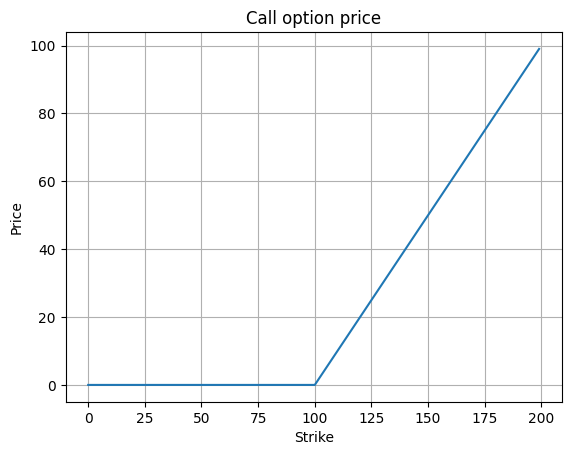

In [4]:
# Checking the call prices with respect to strikes
r, T, t, sigma, K, S = .02, 1, 1, .2, 100, np.arange(200)
plt.plot(S, bs_price_call(S, K, T, t, r, sigma))
plt.xlabel("Strike")
plt.ylabel("Price")
plt.title("Call option price" )
plt.grid()

### Data generation

In [5]:
def bs_LHS_data_generator(n = 10**6, l_bounds = [.4, .2, .02, .01], u_bounds = [1.6, 1.1, .1, 1]):
  """
  Generates samples of call prices using Latin hypercube sampling.
  Returns a torch float tensor of dimension (n,5) containig the inputs samples and the value of the call.
  The inputs are: Moneyness (S/K), time to maturity (tau), Risk free rate (r), Volatility (sigma).
  n: number of samples.
  l_bounds: lower bound for the inputs.  
  u_bounds: upper bound for the inputs.

  """
  sampler = qmc.LatinHypercube(d = 4)
  sample = sampler.random(n)
  sample = qmc.scale(sample, l_bounds, u_bounds)
  bs_prices = bs_moneyness_call(sample[:, 0], sample[:, 1], sample[:, 2], sample[:, 3]).reshape((-1, 1))
  bs_dataset = np.concatenate((sample, bs_prices), axis=1)

  print("------ INPUT ------")
  print("S/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,0]),max(bs_dataset[:,0])))
  print("Tau.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,1]),max(bs_dataset[:,1])))
  print("r............ [{:.2f} {:.2f}]".format(min(bs_dataset[:,2]),max(bs_dataset[:,2])))
  print("Sigma........ [{:.2f} {:.2f}]".format(min(bs_dataset[:,3]),max(bs_dataset[:,3])))
  print("------ OUTPUT ------")
  print("V/K.......... [{:.2f} {:.2f}]".format(min(bs_dataset[:,4]),max(bs_dataset[:,4])))


  return torch.FloatTensor(bs_dataset)

# Testing the function
bs_dataset = bs_LHS_data_generator()

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.90]


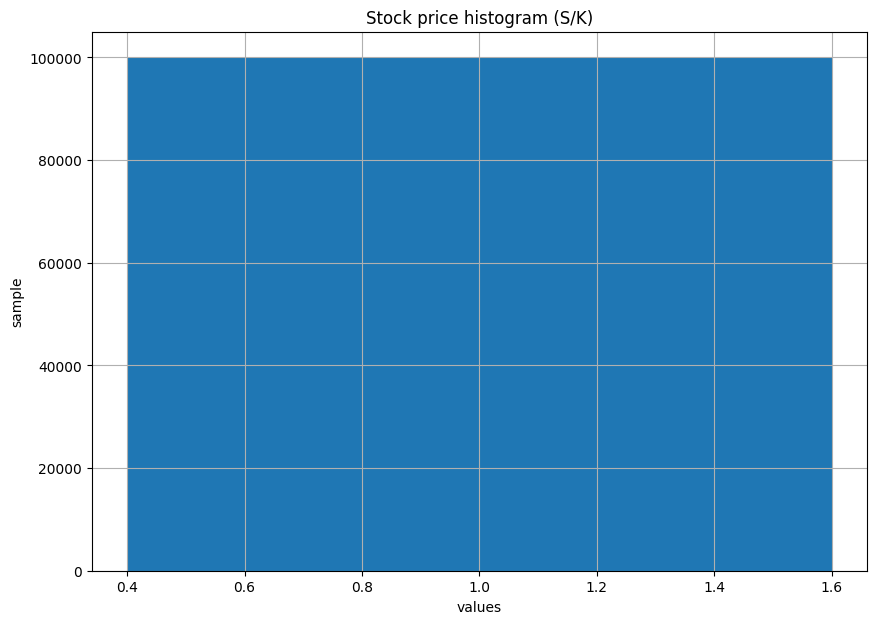

In [9]:
# Checking the LHS distribution of the input
plt.figure(figsize=(10, 7))
h = plt.hist(bs_dataset[:,0], bins= 10)
plt.xlabel("values")
plt.ylabel("sample")
plt.title("Stock price histogram (S/K)" )
plt.grid()

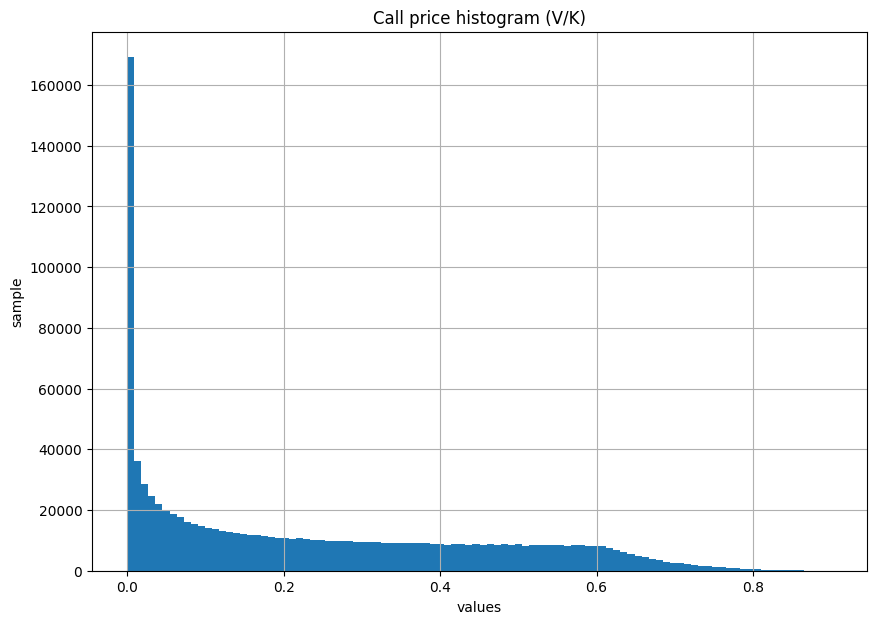

In [10]:
# Checking the output distribution (V/K).
plt.figure(figsize=(10, 7))
h = plt.hist(bs_dataset[:,-1], bins=100)
plt.xlabel("values")
plt.ylabel("sample")
plt.title("Call price histogram (V/K)" )
plt.grid()

**Remark:** The majority of option prices are below 0.01

### Defining class BS-ANN

In [6]:
class BS_ANN(nn.Module):
  def __init__(self):
    """
    Initilize BS-ANN netwwork with four hidden layers. 
    Same architecture as the one used in table 2.
    Weight are initialized using Glorot_uniform also known as Xavier_uniform.
    """
    super(BS_ANN, self).__init__()
    # 4 layers
    self.fc1 = nn.Linear(4, 400)
    self.fc2 = nn.Linear(400, 400)
    self.fc3 = nn.Linear(400, 400)
    self.fc4 = nn.Linear(400, 400)
    self.fc5 = nn.Linear(400, 1)
    # initilizing the layer's weights
    torch.nn.init.xavier_uniform_(self.fc1.weight)
    torch.nn.init.xavier_uniform_(self.fc2.weight)
    torch.nn.init.xavier_uniform_(self.fc3.weight)
    torch.nn.init.xavier_uniform_(self.fc4.weight)
    torch.nn.init.xavier_uniform_(self.fc5.weight)


  def forward(self, x):
    """
    Foward pass of the network. 
    Relu activations are used and a linear activation is used in the final layer.
    x: input torch tensor (CUDA or CPU)
    """
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = F.relu(self.fc4(x))
    x = self.fc5(x)
    return x.flatten()

  def train_model(self, args, device, train_loader, optimizer, epoch):
    """
    Training over train_loader batches for one epoch.
    Returns average training loss.
    args: training parameters.
    device: CUDA or CPU.
    train_loader: train data loader.
    optimizer: gradient descent optmizer.
    epoch: current epoch.
    """
    # train mode
    self.train()
    train_loss = 0
    # loop over data loader
    for batch_idx, data in enumerate(train_loader):
      # extracting the inputs and target
      data, target = data[:,:-1].to(device), data[:,-1].to(device)
      # zeroing the gradients
      optimizer.zero_grad()
      # foward pass
      output = self(data)
      # computing the loss
      loss = F.mse_loss(output, target)
      train_loss += loss.item() *data.shape[0]
      # back propagation
      loss.backward()
      # updating the optimizer step
      optimizer.step()
      # printing batch information
      if batch_idx % args["log_interval"] == 0:
        print('Train Epoch: {} [{}/{} ({:.0f}%)]\tlog Loss: {:.6f}'.format(
            epoch, int(batch_idx / len(train_loader)*len(train_loader.dataset)), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), np.log(loss.item())))
        if args["dry_run"]:
          break
    train_loss /= len(train_loader.dataset)
    print('\nTrain set: Average log loss: {:.4f}\n'.format(np.log(train_loss))) 
    return train_loss


  def test_model(self, device, test_loader):
    """
    Testing over test_loader batches for one epoch. 
    Returns average test loss.
    device: CUDA or CPU.
    test_loader: test data loader.
    """
    # evaluation mode
    self.eval()
    test_loss = 0
    # freezing the gradients
    with torch.no_grad():
      # looping over the test laoder
      for data in test_loader:
        # extracting the inputs and target
        data, target = data[:,:-1].to(device), data[:,-1].to(device)
        # foward pass
        output = self(data)
        #computing the loss
        test_loss += F.mse_loss(output, target, reduction='sum').item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(np.log(test_loss))) 
    return test_loss

### Search of optimal Learning rate interval

In [7]:
# Setting the Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 1024,
         "epochs" : 200,
         "lr": 1,
         "gamma": 1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 10**6,
         "dry_run" : False,
         "save_model": False}

use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])

# loading Train / Test Data
bs_dataset = bs_LHS_data_generator(n = 10**4)
train_size, test_size = int(bs_dataset.shape[0] * 0.9), int(bs_dataset.shape[0] * 0.1 )
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset, args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])


# Model training with Linear increase of the learning rate
model = BS_ANN().to(device)
# Adam optmizer
optimizer = optim.Adam(model.parameters(), lr = args["lr"])
# Linear increase of LR
lambda1 = lambda epoch: 10**(-9 + epoch*10/(args["epochs"] - 1) )
scheduler = LambdaLR(optimizer, lr_lambda = lambda1)


train_losses = []
test_losses = []
lrs = []
# Training loop over epochs
for epoch in range(1, args["epochs"] + 1):
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  lrs.append(scheduler.get_last_lr())
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
  if args["save_model"] & (epoch % 10**3) ==0:
    torch.save(model.state_dict(), "BS_ANN"+str(epoch)+".pt")
    


------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.90]
Current Learning rate 1e-09
Train Epoch: 1 [0/9000 (0%)]	log Loss: -1.930935

Train set: Average log loss: -1.9048


Test set: Average loss: -1.9337

Current Learning rate 1.122667773510816e-09
Train Epoch: 2 [0/9000 (0%)]	log Loss: -1.930952

Train set: Average log loss: -1.9048


Test set: Average loss: -1.9337

Current Learning rate 1.2603829296797274e-09
Train Epoch: 3 [0/9000 (0%)]	log Loss: -1.930970

Train set: Average log loss: -1.9048


Test set: Average loss: -1.9337

Current Learning rate 1.4149912974345788e-09
Train Epoch: 4 [0/9000 (0%)]	log Loss: -1.930989

Train set: Average log loss: -1.9048


Test set: Average loss: -1.9337

Current Learning rate 1.5885651294280526e-09
Train Epoch: 5 [0/9000 (0%)]	log Loss: -1.931011

Train set: Average log loss: -1.9049


Test set: Average loss: -1.9337

Current Lear

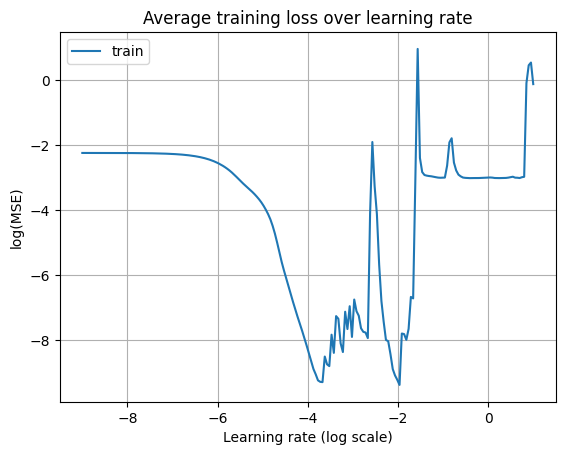

In [14]:
# Plotting the log MSE as a funtion of the learning rate
plt.plot(np.log10(lrs), np.log(train_losses), label = "train")
plt.xlabel("Learning rate (log scale)")
plt.ylabel("log(MSE)")
plt.title("Average training loss over learning rate" )
plt.grid()
plt.legend()

**Remark:** it seems like the best interval is from $10^{-4}$ to $10^{-6}$

### Training BS-ANN with DecayLR from $10^{-4}$ to $10^{-6}$ Wide dataset

In [15]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
bs_dataset = bs_LHS_data_generator(n = 10**5)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])



print(device)
model = BS_ANN().to(device)
# Adam is found to be the best optimizer in the article
optimizer = optim.Adam(model.parameters(), lr = args["lr"]) 
# Deacreses the Learning rate by .1 every 1000 epoch
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) 

train_losses = []
test_losses = []
# Training loop
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "BS_ANN.pt")
    

------ INPUT ------
S/K.......... [0.40 1.60]
Tau.......... [0.20 1.10]
r............ [0.02 0.10]
Sigma........ [0.01 1.00]
------ OUTPUT ------
V/K.......... [0.00 0.87]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -1.975925

Train set: Average log loss: -4.1525


Test set: Average loss: -6.6023

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -6.562607

Train set: Average log loss: -7.3056


Test set: Average loss: -8.0495

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -7.991403

Train set: Average log loss: -8.4908


Test set: Average loss: -9.0149

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -8.977956

Train set: Average log loss: -9.2991


Test set: Average loss: -9.6424

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -9.633021

Train set: Average log loss: -9.8366


Test set: Average loss: -10.0792

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -10.083089

Train set: 

Training WIDE 2.1266650261648264e-08 VS in the article 8.04e-09


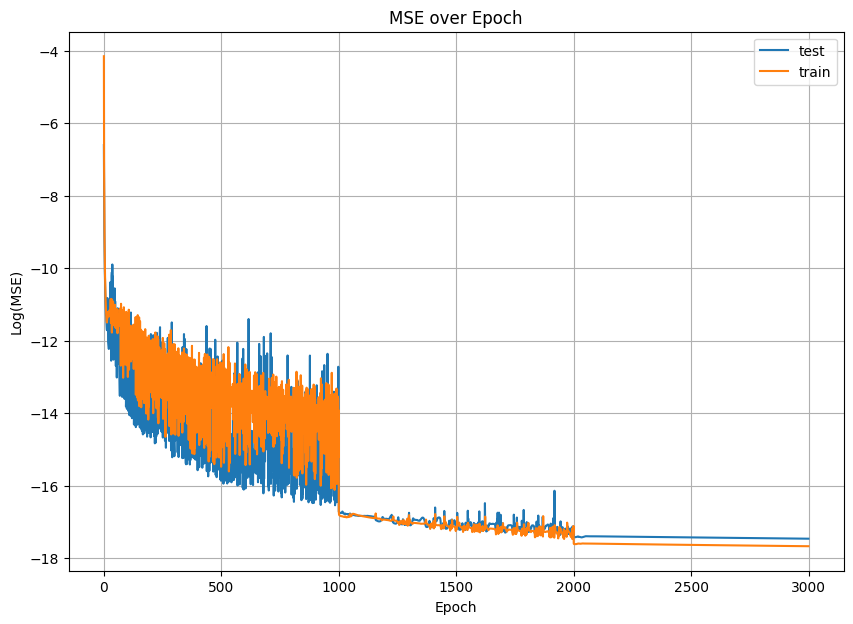

In [16]:
# Plotting the Log(MSE) with respect to the epoch
plt.figure(figsize=(10,7))
plt.plot( np.log(test_losses), label = "test")
plt.plot( np.log(train_losses), label = "train")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Log(MSE)")
plt.title("MSE over Epoch" )
plt.grid()
print("Training WIDE {} VS in the article 8.04e-09".format(train_losses[-1]) )

In [17]:
# Loading model from saved parameters
loaded_BS_ANN = BS_ANN().to(device)
PATH = "ANN_weights/BS_ANN.pt"
loaded_BS_ANN.load_state_dict(torch.load(PATH))
loaded_BS_ANN.eval()


BS_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

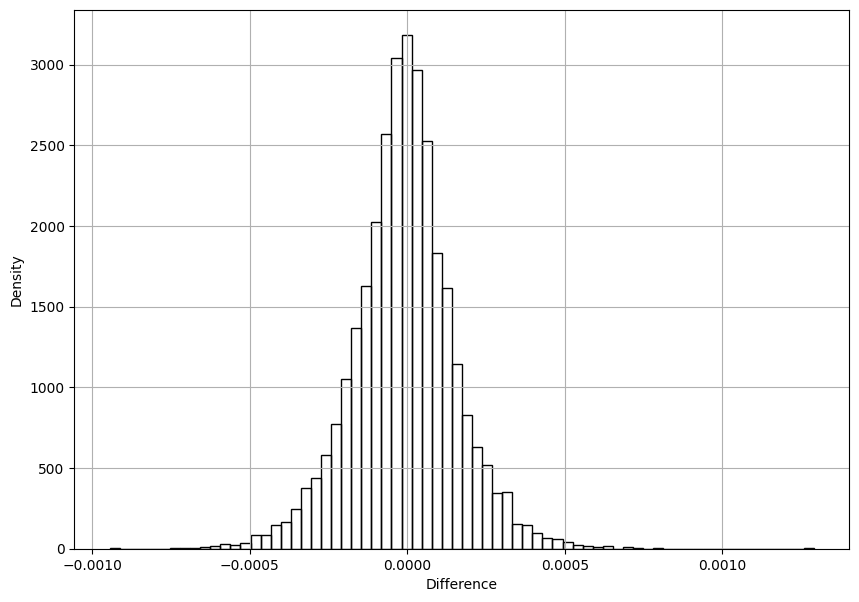

MAX  0.0012913942
MIN  -0.0009447932
Total area under the histogram: 1.0000000020547326
Total area under the histogram: 1.0000000020547326


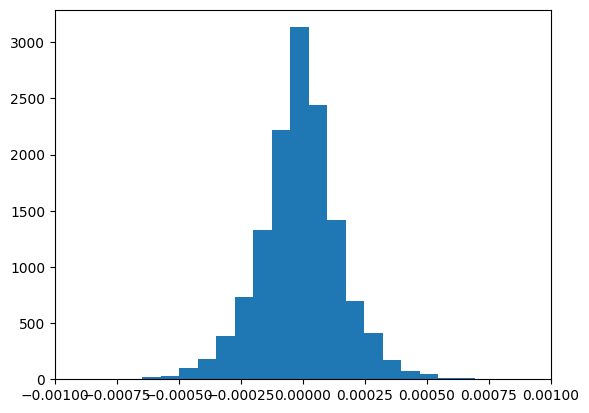

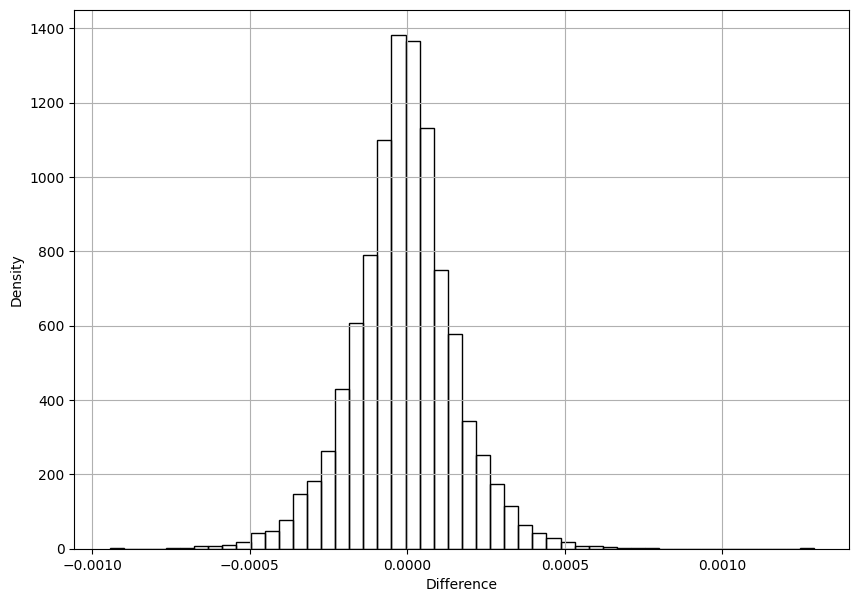

MAX  0.0012913942
MIN  -0.0009447932


In [30]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
#plt.hist(errors, 50, fill=False)
plt.hist(errors, bins=70, fill=False, density=True)  # Try fewer bins
#plt.xlim([errors.min(), errors.max()])  # Set xlim based on data range
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())
plt.xlim([-0.001, 0.001])
# Check if the area under the curve sums to 1
counts, bins, patches = plt.hist(errors, bins=30, density=True)
area = np.sum(counts * np.diff(bins))
print(f"Total area under the histogram: {area}")
area = np.sum(counts * np.diff(bins))
print(f"Total area under the histogram: {area}")

plt.figure(figsize=(10,7))
plt.hist(errors, 50, fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())

In [16]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 2.661910e-08
MAE 1.212079e-04
MAPE 1.225685e-01
R2 9.999994e-01
-----------Test scores----------------
MSE 2.658838e-08
MAE 1.208108e-04
MAPE 1.125771e-01
R2 9.999994e-01


In [17]:
np.sqrt(2.597518e-08)

0.00016116817303673826

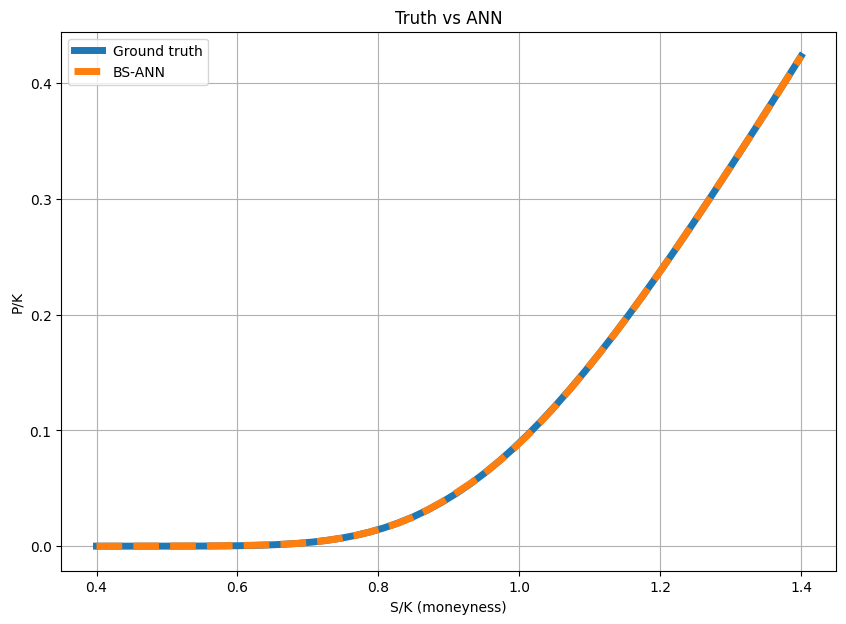

In [18]:
# Replace this with a matrix
moneyness = np.linspace(0.4,1.4)
tau, r, sigma = 1, .02, .2
prices = bs_moneyness_call(moneyness, tau, r, sigma)

plot_dateset = np.ones((50,4))
plot_dateset[:,0] = moneyness
plot_dateset[:,1] = plot_dateset[:,1]*tau
plot_dateset[:,2] = plot_dateset[:,2]*r
plot_dateset[:,3] = plot_dateset[:,3]*sigma


plt.figure(figsize=(10,7))
plt.plot(moneyness, prices, label="Ground truth", linewidth=5 )


plot_dateset = torch.from_numpy(plot_dateset).type(torch.FloatTensor).to(device)
output = loaded_BS_ANN(plot_dateset)
plt.plot(moneyness, output.data.cpu().numpy(), "--", label="BS-ANN", linewidth=5)

plt.legend()
plt.xlabel("S/K (moneyness)")
plt.ylabel("P/K")
plt.title("Truth vs ANN" )
plt.grid()

### Training BS-ANN with DecayLR from $10^{-4}$ to $10^{-6}$ Narrow dataset 

In [19]:
# Training parameters
args =  {"batch_size": 1024,
         "test_batch_size": 4048,
         "epochs" : 3*10**3,
         "lr": 1e-4,
         "gamma": .1,
         "no_cuda" : False,
         "run_dry": False,
         "seed": 0,
         "log_interval" : 100,
         "dry_run" : False,
         "save_model": True}



use_cuda = not args["no_cuda"] and torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
# torch.manual_seed(args["seed"])


# Loading Train / Test Data
l_bounds = [.5, .3, .03, .02]
u_bounds = [1.5, .95, .08, .9]
bs_dataset = bs_LHS_data_generator(n = 10**5,l_bounds=l_bounds, u_bounds=u_bounds)
train_size, test_size = int(bs_dataset.shape[0]*0.9), int(bs_dataset.shape[0]*0.1 ) # 10% SPLIT
train_dataset, test_dataset = torch.utils.data.random_split(bs_dataset, [train_size, test_size])

train_loader = torch.utils.data.DataLoader(train_dataset,args["batch_size"])
test_loader = torch.utils.data.DataLoader(test_dataset, args["test_batch_size"])



print(device)
model = BS_ANN().to(device)
# Adam is found to be the best optimizer in the article
optimizer = optim.Adam(model.parameters(), lr=args["lr"]) 
# Deacreses the Learning rate by .1 every 1000 epoch
scheduler = StepLR(optimizer, step_size=10**3, gamma=args["gamma"]) 

train_losses = []
test_losses = []
# Training loop
for epoch in range(1, args["epochs"] + 1):
  train_loss = model.train_model(args, device, train_loader, optimizer, epoch)
  test_loss = model.test_model(device, test_loader)
  print("Current Learning rate {}".format(scheduler.get_last_lr()[0]))
  scheduler.step()
  train_losses.append(train_loss)
  test_losses.append(test_loss)
if args["save_model"] :
  torch.save(model.state_dict(), "BS_ANN_narrow.pt")
    

------ INPUT ------
S/K.......... [0.50 1.50]
Tau.......... [0.30 0.95]
r............ [0.03 0.08]
Sigma........ [0.02 0.90]
------ OUTPUT ------
V/K.......... [0.00 0.73]
cuda
Train Epoch: 1 [0/90000 (0%)]	log Loss: -2.550454

Train set: Average log loss: -4.5893


Test set: Average loss: -6.8246

Current Learning rate 0.0001
Train Epoch: 2 [0/90000 (0%)]	log Loss: -6.841770

Train set: Average log loss: -7.4855


Test set: Average loss: -8.2328

Current Learning rate 0.0001
Train Epoch: 3 [0/90000 (0%)]	log Loss: -8.313316

Train set: Average log loss: -8.6803


Test set: Average loss: -9.1286

Current Learning rate 0.0001
Train Epoch: 4 [0/90000 (0%)]	log Loss: -9.270951

Train set: Average log loss: -9.4476


Test set: Average loss: -9.7445

Current Learning rate 0.0001
Train Epoch: 5 [0/90000 (0%)]	log Loss: -9.892994

Train set: Average log loss: -10.0354


Test set: Average loss: -10.1791

Current Learning rate 0.0001
Train Epoch: 6 [0/90000 (0%)]	log Loss: -10.310810

Train set:

In [20]:
# Loading model from saved parameters
loaded_BS_ANN = BS_ANN().to(device)
PATH = "ANN_weights/BS_ANN_narrow.pt"
loaded_BS_ANN.load_state_dict(torch.load(PATH))
loaded_BS_ANN.eval()


BS_ANN(
  (fc1): Linear(in_features=4, out_features=400, bias=True)
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=400, bias=True)
  (fc5): Linear(in_features=400, out_features=1, bias=True)
)

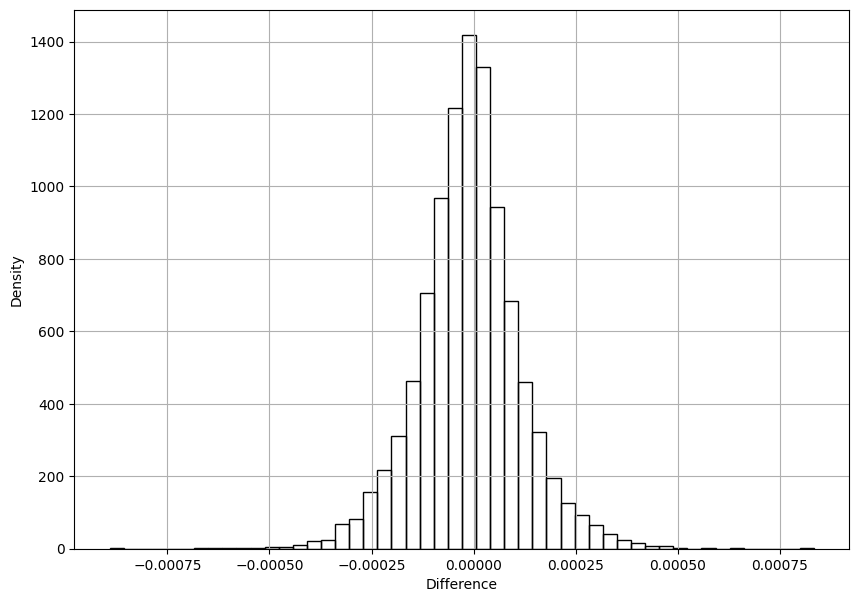

MAX  0.0008338839
MIN  -0.0008913651


In [21]:
# Plotting erros histogram
errors = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    errors.append((target-output).data.cpu().numpy())
  errors = np.concatenate(errors)
plt.figure(figsize=(10,7))
plt.hist(errors,50,fill=False)
plt.grid()
plt.xlabel("Difference")
plt.ylabel("Density")
plt.show()
print("MAX ",errors.max())
print("MIN ",errors.min())


In [22]:
# Printing train and test MSE, MAE, MAPE and R2
outputs = []
targets = []
with torch.no_grad():
  for data in train_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Train scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )


outputs = []
targets = []
with torch.no_grad():
  for data in test_loader:
    data, target = data[:,:-1].to(device), data[:,-1].to(device)
    output = loaded_BS_ANN(data)
    outputs.append((output).data.cpu().numpy())
    targets.append((target).data.cpu().numpy())
  outputs = np.concatenate(outputs)
  targets = np.concatenate(targets)

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
print("-----------Test scores----------------")
print("MSE {:e}".format(mean_squared_error(outputs,targets)) )
print("MAE {:e}".format(mean_absolute_error(outputs,targets)) )
print("MAPE {:e}".format(mean_absolute_percentage_error(outputs,targets)) )
print("R2 {:e}".format(r2_score(outputs,targets)) )

-----------Train scores----------------
MSE 1.578677e-08
MAE 9.406319e-05
MAPE 9.084946e-02
R2 9.999995e-01
-----------Test scores----------------
MSE 1.529350e-08
MAE 9.230250e-05
MAPE 9.723768e-02
R2 9.999995e-01


In [23]:
np.sqrt(1.554532e-08)

0.00012468087263088913